In [26]:
pip install geopy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 25.0.1
[notice] To update, run: C:\Users\afats\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [27]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from geopy.distance import geodesic
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset (Replace 'your_data.csv' with the actual dataset)
df = pd.read_csv('C:/Users/afats/Downloads/fooddelivery.csv')

# Check the first few rows of the data
print(df.head())


     ID Delivery_person_ID  Delivery_person_Age  Delivery_person_Ratings  \
0  4607     INDORES13DEL02                   37                      4.9   
1  B379     BANGRES18DEL02                   34                      4.5   
2  5D6D     BANGRES19DEL01                   23                      4.4   
3  7A6A    COIMBRES13DEL02                   38                      4.7   
4  70A2     CHENRES12DEL01                   32                      4.6   

   Restaurant_latitude  Restaurant_longitude  Delivery_location_latitude  \
0            22.745049             75.892471                   22.765049   
1            12.913041             77.683237                   13.043041   
2            12.914264             77.678400                   12.924264   
3            11.003669             76.976494                   11.053669   
4            12.972793             80.249982                   13.012793   

   Delivery_location_longitude Type_of_order Type_of_vehicle  Time_taken(min)  
0     

In [28]:
# Import the necessary library for distance calculation
from geopy.distance import geodesic

# Calculate the distance between restaurant and delivery location
def calculate_distance(row):
    restaurant_coords = (row['Restaurant_latitude'], row['Restaurant_longitude'])
    delivery_coords = (row['Delivery_location_latitude'], row['Delivery_location_longitude'])
    return geodesic(restaurant_coords, delivery_coords).km  # distance in kilometers

# Apply the distance calculation function to the dataset
df['Distance_km'] = df.apply(calculate_distance, axis=1)

# Display the first few rows to check the new feature (Distance_km)
df[['Restaurant_latitude', 'Restaurant_longitude', 'Delivery_location_latitude', 'Delivery_location_longitude', 'Distance_km']].head()


,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Distance_km
0,22.745049,75.892471,22.765049,75.912471,3.020737
1,12.913041,77.683237,13.043041,77.813237,20.143737
2,12.914264,77.678400,12.924264,77.688400,1.549693
3,11.003669,76.976494,11.053669,77.026494,7.774497
4,12.972793,80.249982,13.012793,80.289982,6.197898


In [29]:
# Drop unnecessary columns
df = df.drop(['ID', 'Delivery_person_ID', 'Restaurant_latitude', 'Restaurant_longitude',
              'Delivery_location_latitude', 'Delivery_location_longitude'], axis=1)

# One-hot encode categorical variables like 'Type_of_order' and 'Type_of_vehicle'
df = pd.get_dummies(df, columns=['Type_of_order', 'Type_of_vehicle'], drop_first=True)

# Display the updated dataset to confirm changes
df.head()


,Delivery_person_Age,Delivery_person_Ratings,Time_taken(min),Distance_km,Type_of_order_Drinks,Type_of_order_Meal,Type_of_order_Snack,Type_of_vehicle_electric_scooter,Type_of_vehicle_motorcycle,Type_of_vehicle_scooter
0,37,4.9,24,3.020737,False,False,True,False,True,False
1,34,4.5,33,20.143737,False,False,True,False,False,True
2,23,4.4,26,1.549693,True,False,False,False,True,False
3,38,4.7,21,7.774497,False,False,False,False,True,False
4,32,4.6,30,6.197898,False,False,True,False,False,True


In [30]:
from sklearn.model_selection import train_test_split

# Separate features and target variable
X = df.drop('Time_taken(min)', axis=1)  # Features
y = df['Time_taken(min)']  # Target variable

# Split the data into training and testing sets (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Display the shapes of the split data
print(f'Training set shape: X_train = {X_train.shape}, y_train = {y_train.shape}')
print(f'Testing set shape: X_test = {X_test.shape}, y_test = {y_test.shape}')


Training set shape: X_train = (36474, 9), y_train = (36474,)
Testing set shape: X_test = (9119, 9), y_test = (9119,)


In [31]:
from sklearn.preprocessing import StandardScaler

# Initialize the scaler
scaler = StandardScaler()

# Fit and transform the training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform the testing data (use the same scaler as the training data)
X_test_scaled = scaler.transform(X_test)

# Display the scaled data (optional)
X_train_scaled[:5]


array([[ 1.30573868,  0.51011724, -0.08883628, -0.57353014, -0.57737137,
        -0.58678503, -0.30251124,  0.84875824, -0.70732489],
       [-0.27410738, -1.3198627 , -0.0860166 , -0.57353014, -0.57737137,
        -0.58678503, -0.30251124,  0.84875824, -0.70732489],
       [-0.97626118, -0.09987608, -0.08070557, -0.57353014, -0.57737137,
        -0.58678503, -0.30251124,  0.84875824, -0.70732489],
       [ 0.77912333, -1.92985602, -0.08476372, -0.57353014,  1.73198749,
        -0.58678503, -0.30251124, -1.1781918 ,  1.41377748],
       [-0.27410738,  0.51011724, -0.07470239,  1.74358753, -0.57737137,
        -0.58678503, -0.30251124,  0.84875824, -0.70732489]])

In [32]:
from sklearn.ensemble import RandomForestRegressor

# Initialize the Random Forest Regressor model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# Train the model using the scaled training data
rf_model.fit(X_train_scaled, y_train)

# Make predictions on the test set
y_pred = rf_model.predict(X_test_scaled)

# Display the first few predictions
print(f'Predicted delivery times: {y_pred[:5]}')


Predicted delivery times: [33.22       27.60333333 34.74       33.63       25.375     ]


In [33]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Calculate the evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

# Display the evaluation metrics
print(f'Mean Absolute Error (MAE): {mae}')
print(f'Root Mean Squared Error (RMSE): {rmse}')
print(f'R-squared: {r2}')


Mean Absolute Error (MAE): 6.050156617876159
Root Mean Squared Error (RMSE): 7.756145579500694
R-squared: 0.3138791893298898


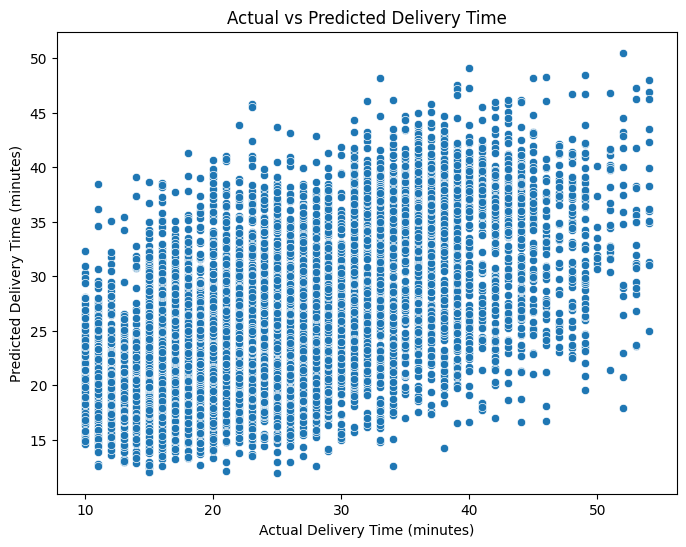

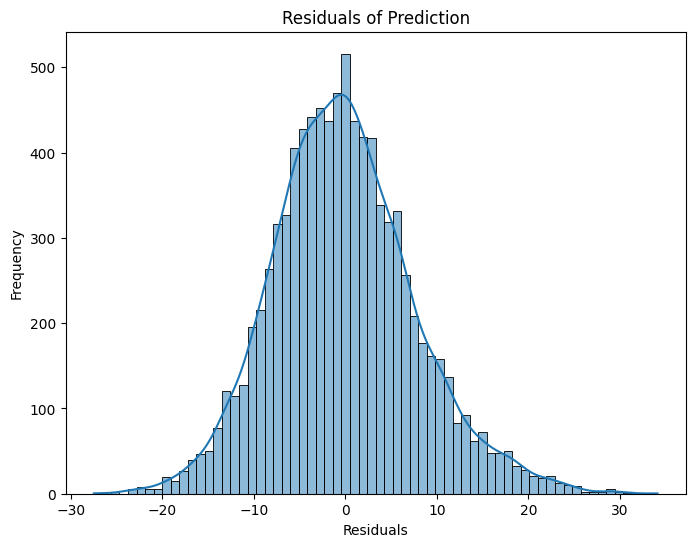

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting actual vs predicted delivery time
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test, y=y_pred)
plt.title('Actual vs Predicted Delivery Time')
plt.xlabel('Actual Delivery Time (minutes)')
plt.ylabel('Predicted Delivery Time (minutes)')
plt.show()

# Residual plot (difference between actual and predicted)
residuals = y_test - y_pred
plt.figure(figsize=(8,6))
sns.histplot(residuals, kde=True)
plt.title('Residuals of Prediction')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.show()


In [35]:
# Load the dataset
df = pd.read_csv("C:/Users/afats/Downloads/fooddelivery.csv")

# Display first few rows
df.head()


,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Type_of_order,Type_of_vehicle,Time_taken(min)
0,4607,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,Snack,motorcycle,24
1,B379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,Snack,scooter,33
2,5D6D,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,Drinks,motorcycle,26
3,7A6A,COIMBRES13DEL02,38,4.7,11.003669,76.976494,11.053669,77.026494,Buffet,motorcycle,21
4,70A2,CHENRES12DEL01,32,4.6,12.972793,80.249982,13.012793,80.289982,Snack,scooter,30


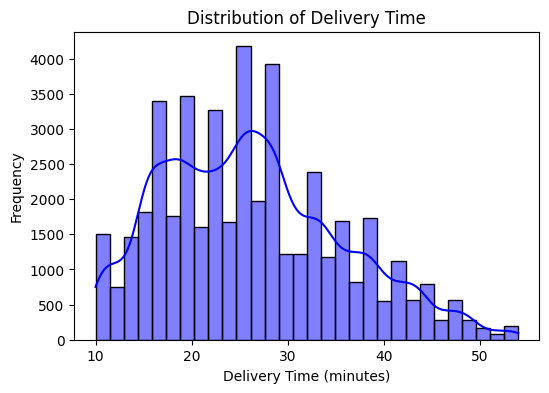

In [36]:
plt.figure(figsize=(6,4))
sns.histplot(df['Time_taken(min)'], bins=30, kde=True, color="blue")
plt.xlabel("Delivery Time (minutes)")
plt.ylabel("Frequency")
plt.title("Distribution of Delivery Time")
plt.show()


In [37]:
# Function to calculate Haversine distance
from geopy.distance import geodesic

def calculate_distance(row):
    restaurant_coords = (row['Restaurant_latitude'], row['Restaurant_longitude'])
    delivery_coords = (row['Delivery_location_latitude'], row['Delivery_location_longitude'])
    return geodesic(restaurant_coords, delivery_coords).km

df['Distance_km'] = df.apply(calculate_distance, axis=1)


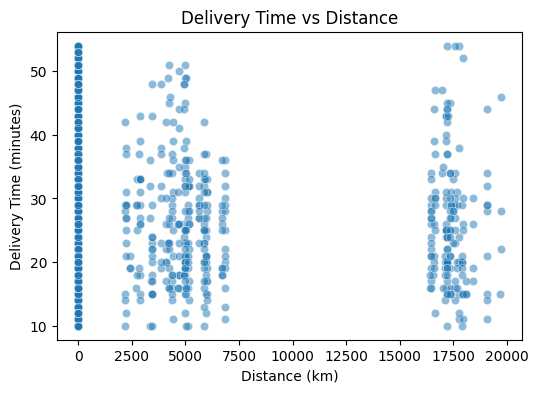

In [38]:
plt.figure(figsize=(6,4))
sns.scatterplot(x=df['Distance_km'], y=df['Time_taken(min)'], alpha=0.5)
plt.xlabel("Distance (km)")
plt.ylabel("Delivery Time (minutes)")
plt.title("Delivery Time vs Distance")
plt.show()
